## Import Libraries

In [95]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error,mean_absolute_percentage_error,root_mean_squared_error

## Load Dataset

In [96]:
df = pd.read_csv('../data/preprocessedData.csv',index_col='Date',parse_dates=True)
df = df.asfreq('MS')

## Train Test Split

In [97]:
periods = 12
train = df.iloc[:-periods,:]
test = df.iloc[-periods:,:]

In [98]:
print('Shape of train: ',train.shape)
print('Shape of test: ',test.shape)

Shape of train:  (101, 1)
Shape of test:  (12, 1)


## Model

In [99]:
model = ExponentialSmoothing(train,
                             trend='mul',
                             seasonal='mul',
                             seasonal_periods=12).fit()

d:\Machine Learning\TimeSeries\timeSeriesENV\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


In [100]:
predictions = model.forecast(steps=len(test))
predictions

2004-06-01    4.989814e+07
2004-07-01    5.232020e+07
2004-08-01    5.246731e+07
2004-09-01    4.147231e+07
2004-10-01    4.632250e+07
2004-11-01    4.366543e+07
2004-12-01    4.583298e+07
2005-01-01    4.142760e+07
2005-02-01    4.104454e+07
2005-03-01    5.053423e+07
2005-04-01    4.798055e+07
2005-05-01    4.852405e+07
Freq: MS, dtype: float64

### Model Assessment

In [101]:
def model_assessment(train,test,predictions,title=None,img_name=None):
    plt.figure(figsize=(10,4))
    plt.plot(train,label = 'Train')
    plt.plot(test,label='Test')
    plt.plot(predictions,label='Predictions')
    plt.title(f"Train, Test and Predictions with {title}")
    plt.legend()
    plt.savefig(f'../visualisations/model_visualizations/{img_name}.png')
    plt.show()
    
    # Calculate the MAE,RMSE,MAPE
    mae = mean_absolute_error(test,predictions)
    rmse = root_mean_squared_error(test,predictions)
    mape = mean_absolute_percentage_error(test,predictions)
    
    print(f'Mean Absolute Error: {mae:.2f}')
    print(f'Root Mean Squared Error: {mae:.2f}')
    print(f'Mean Absolute Percentage Error: {100 * mape:.2f}')

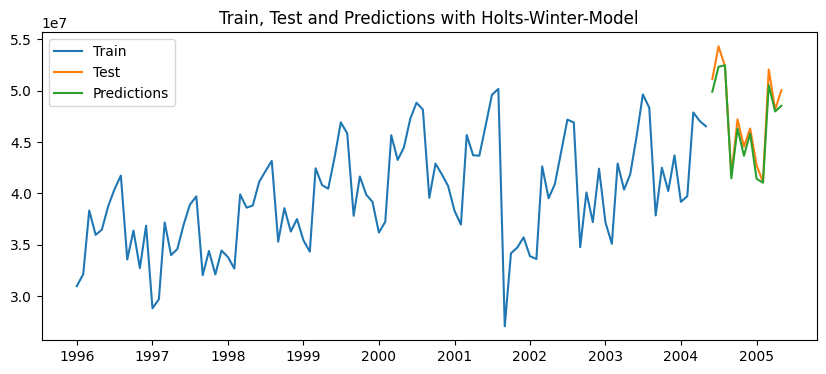

Mean Absolute Error: 877575.16
Root Mean Squared Error: 877575.16
Mean Absolute Percentage Error: 1.80


In [102]:
model_assessment(train=train,test=test,predictions=predictions,title='Holts-Winter-Model',img_name="predict_train")

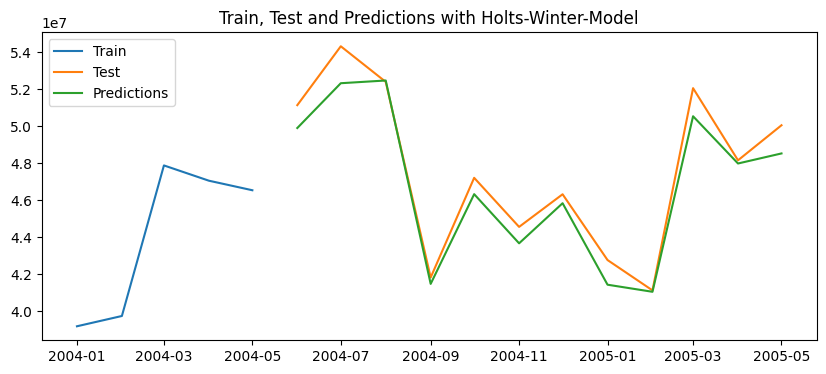

Mean Absolute Error: 877575.16
Root Mean Squared Error: 877575.16
Mean Absolute Percentage Error: 1.80


In [103]:
model_assessment(train.loc['2004'],test,predictions,"Holts-Winter-Model","zoomed-view-train")

# Forecasting

In [104]:
model = ExponentialSmoothing(df['y'],
                             trend='mul',
                             seasonal='mul',
                             seasonal_periods=12).fit()
predictions = model.forecast(steps=12)
predictions

d:\Machine Learning\TimeSeries\timeSeriesENV\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


2005-06-01    5.317705e+07
2005-07-01    5.585684e+07
2005-08-01    5.559980e+07
2005-09-01    4.374628e+07
2005-10-01    4.922822e+07
2005-11-01    4.655935e+07
2005-12-01    4.885796e+07
2006-01-01    4.429477e+07
2006-02-01    4.367190e+07
2006-03-01    5.397746e+07
2006-04-01    5.112520e+07
2006-05-01    5.178827e+07
Freq: MS, dtype: float64

In [105]:
def plot_forecast(y,forecast,title=None,img_name=None):
    plt.figure(figsize=(10,4))
    plt.plot(y,label='Train')
    plt.plot(forecast,label='Forecast')
    plt.title(f"Train and Forecast with {title}")
    plt.legend()
    plt.savefig(f'../visualisations/model_visualizations/{img_name}.png')
    plt.show()

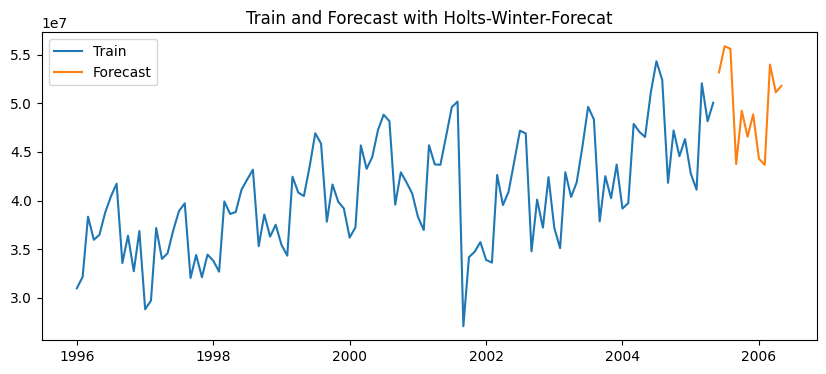

In [106]:
plot_forecast(df['y'],predictions,'Holts-Winter-Forecat',"final-forecast")